GOOD FIT:


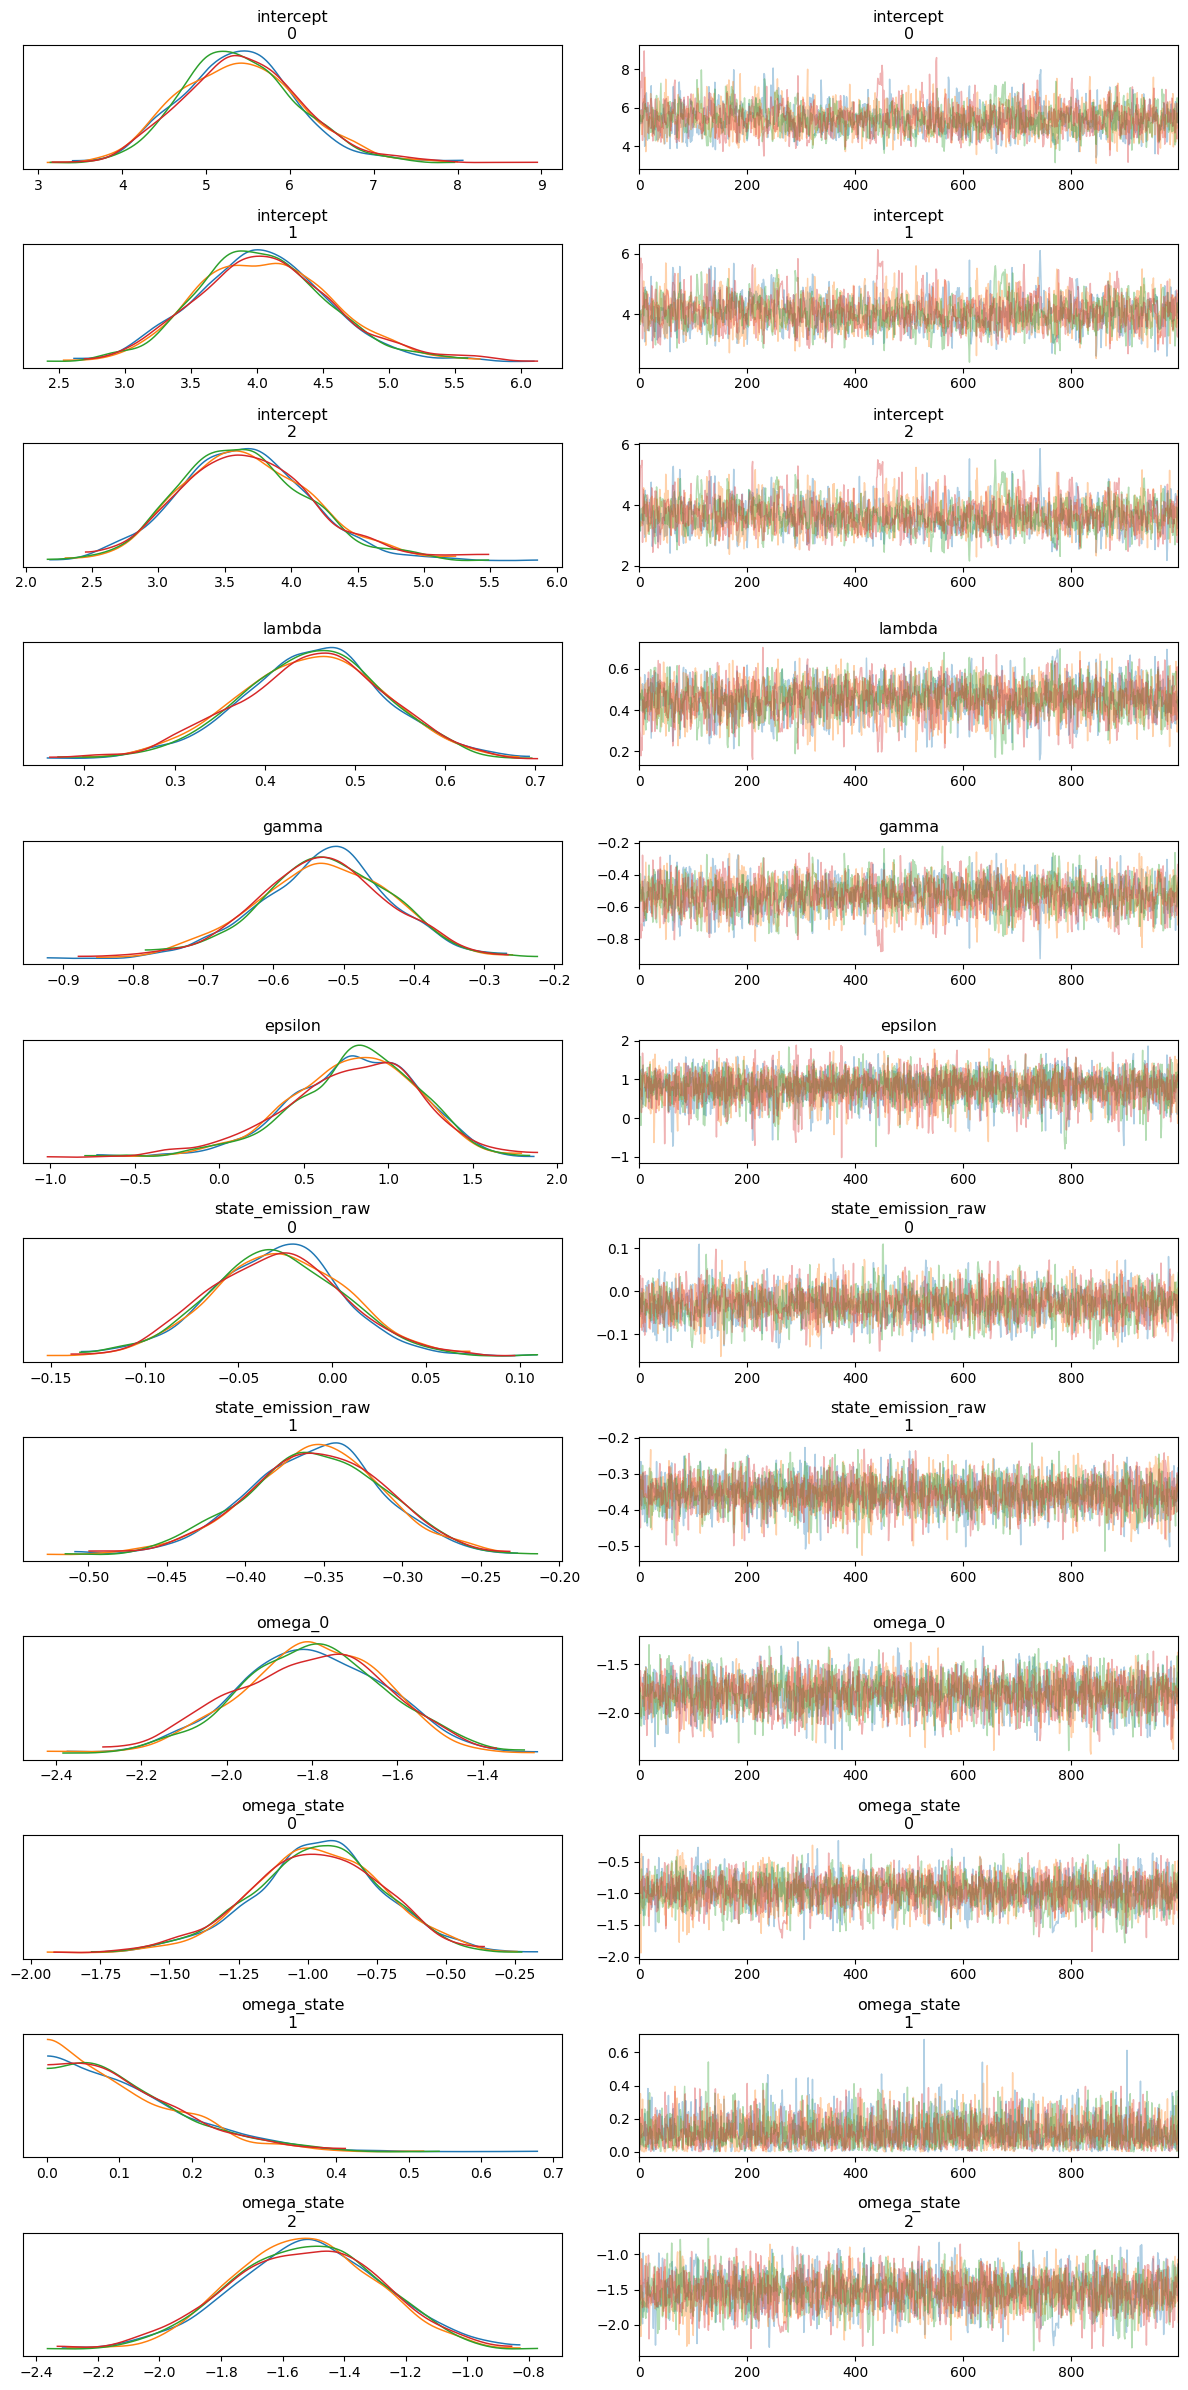

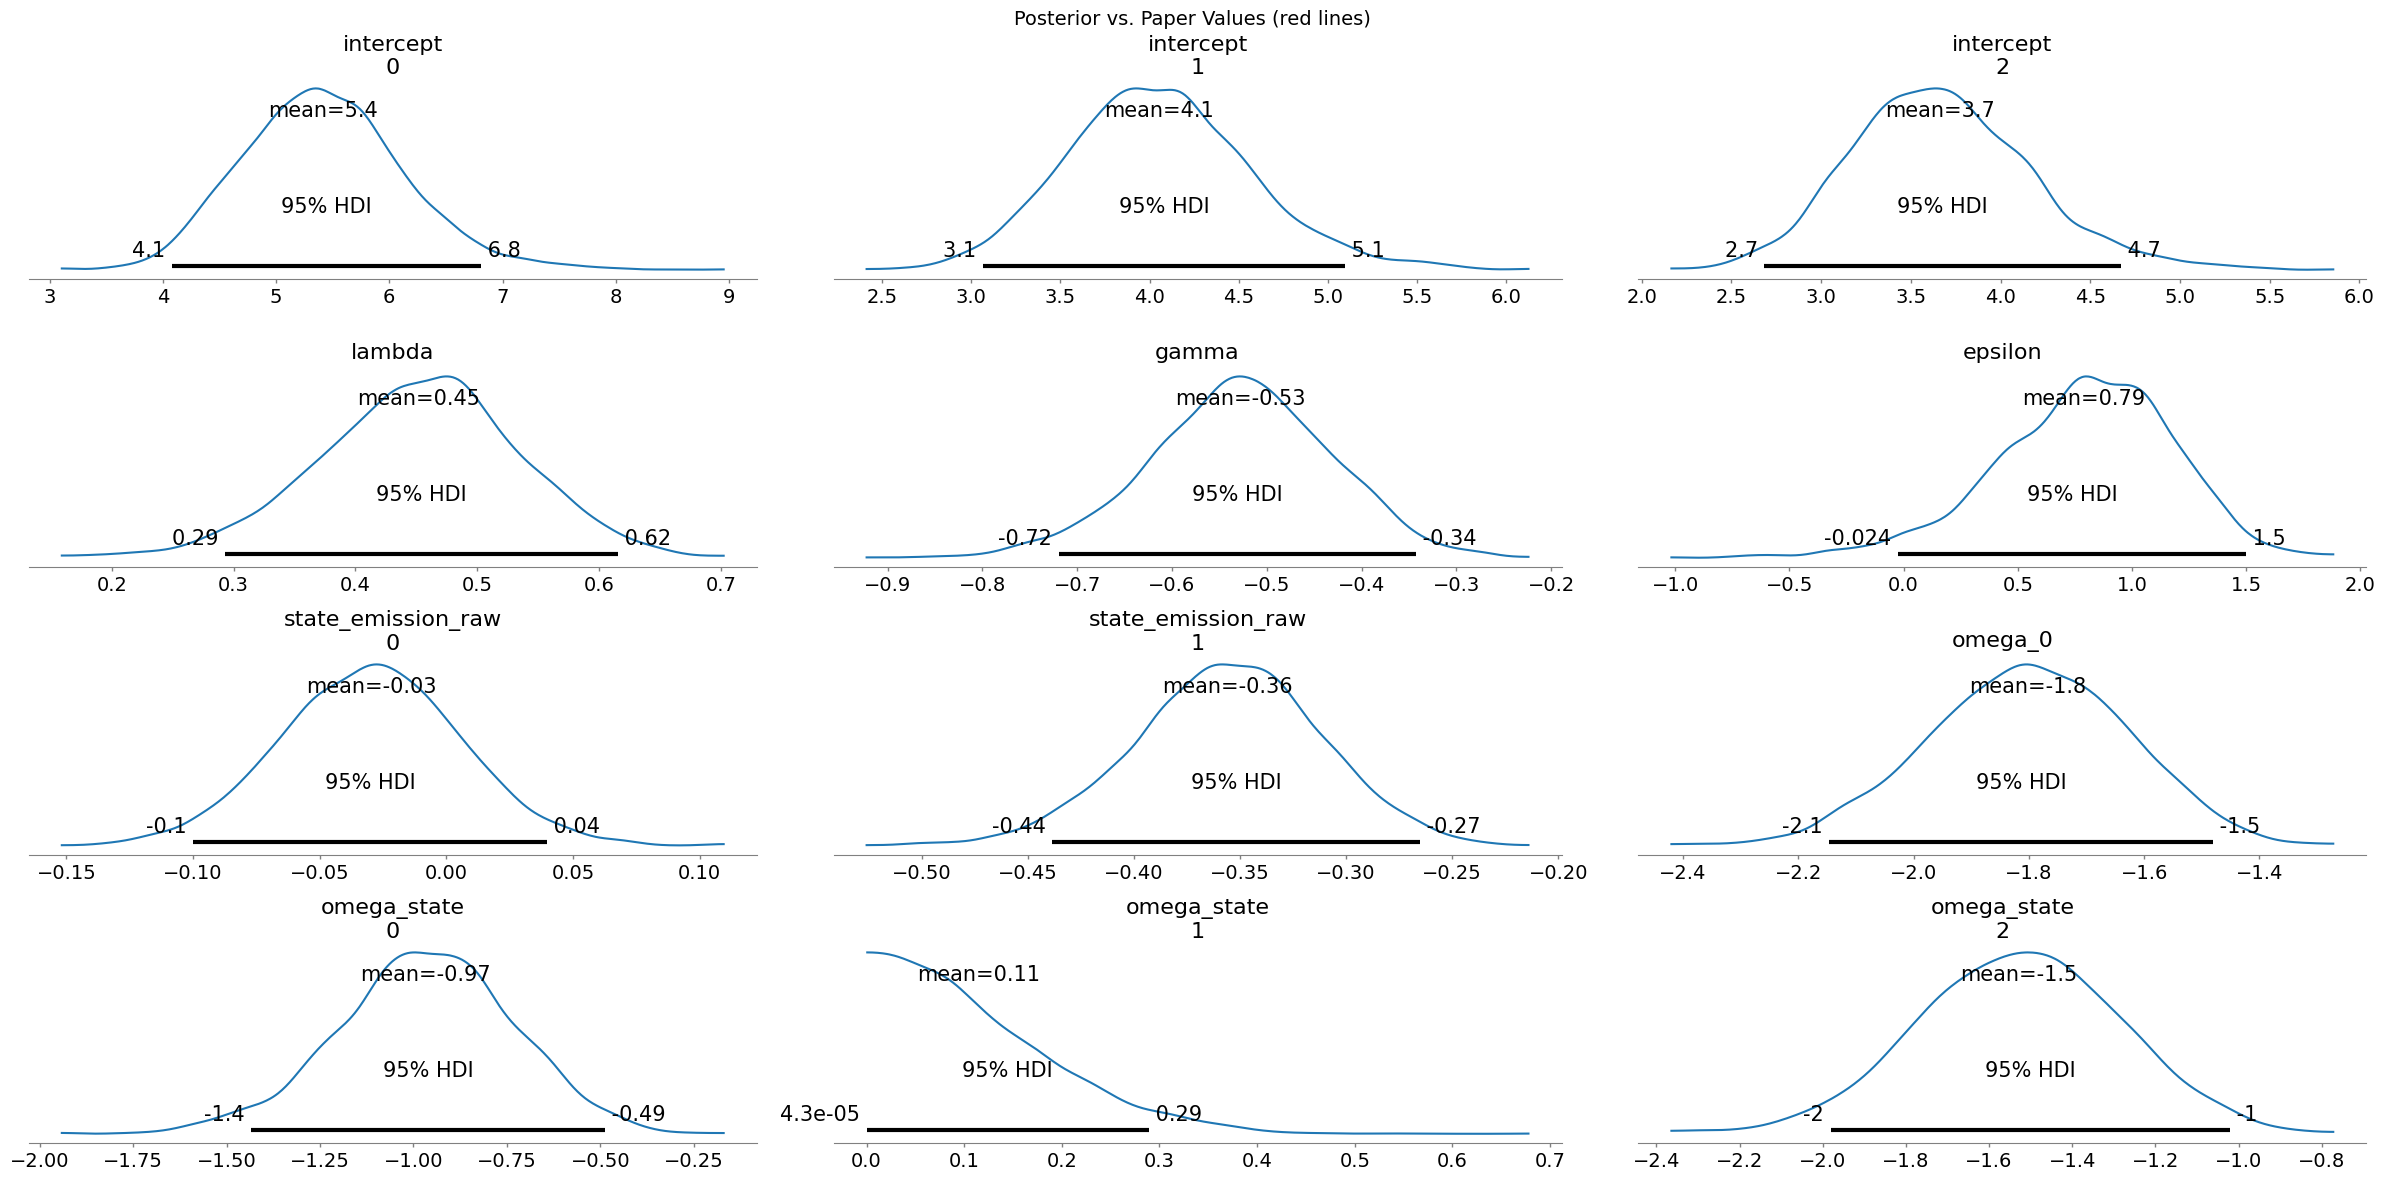

BAD FIT:


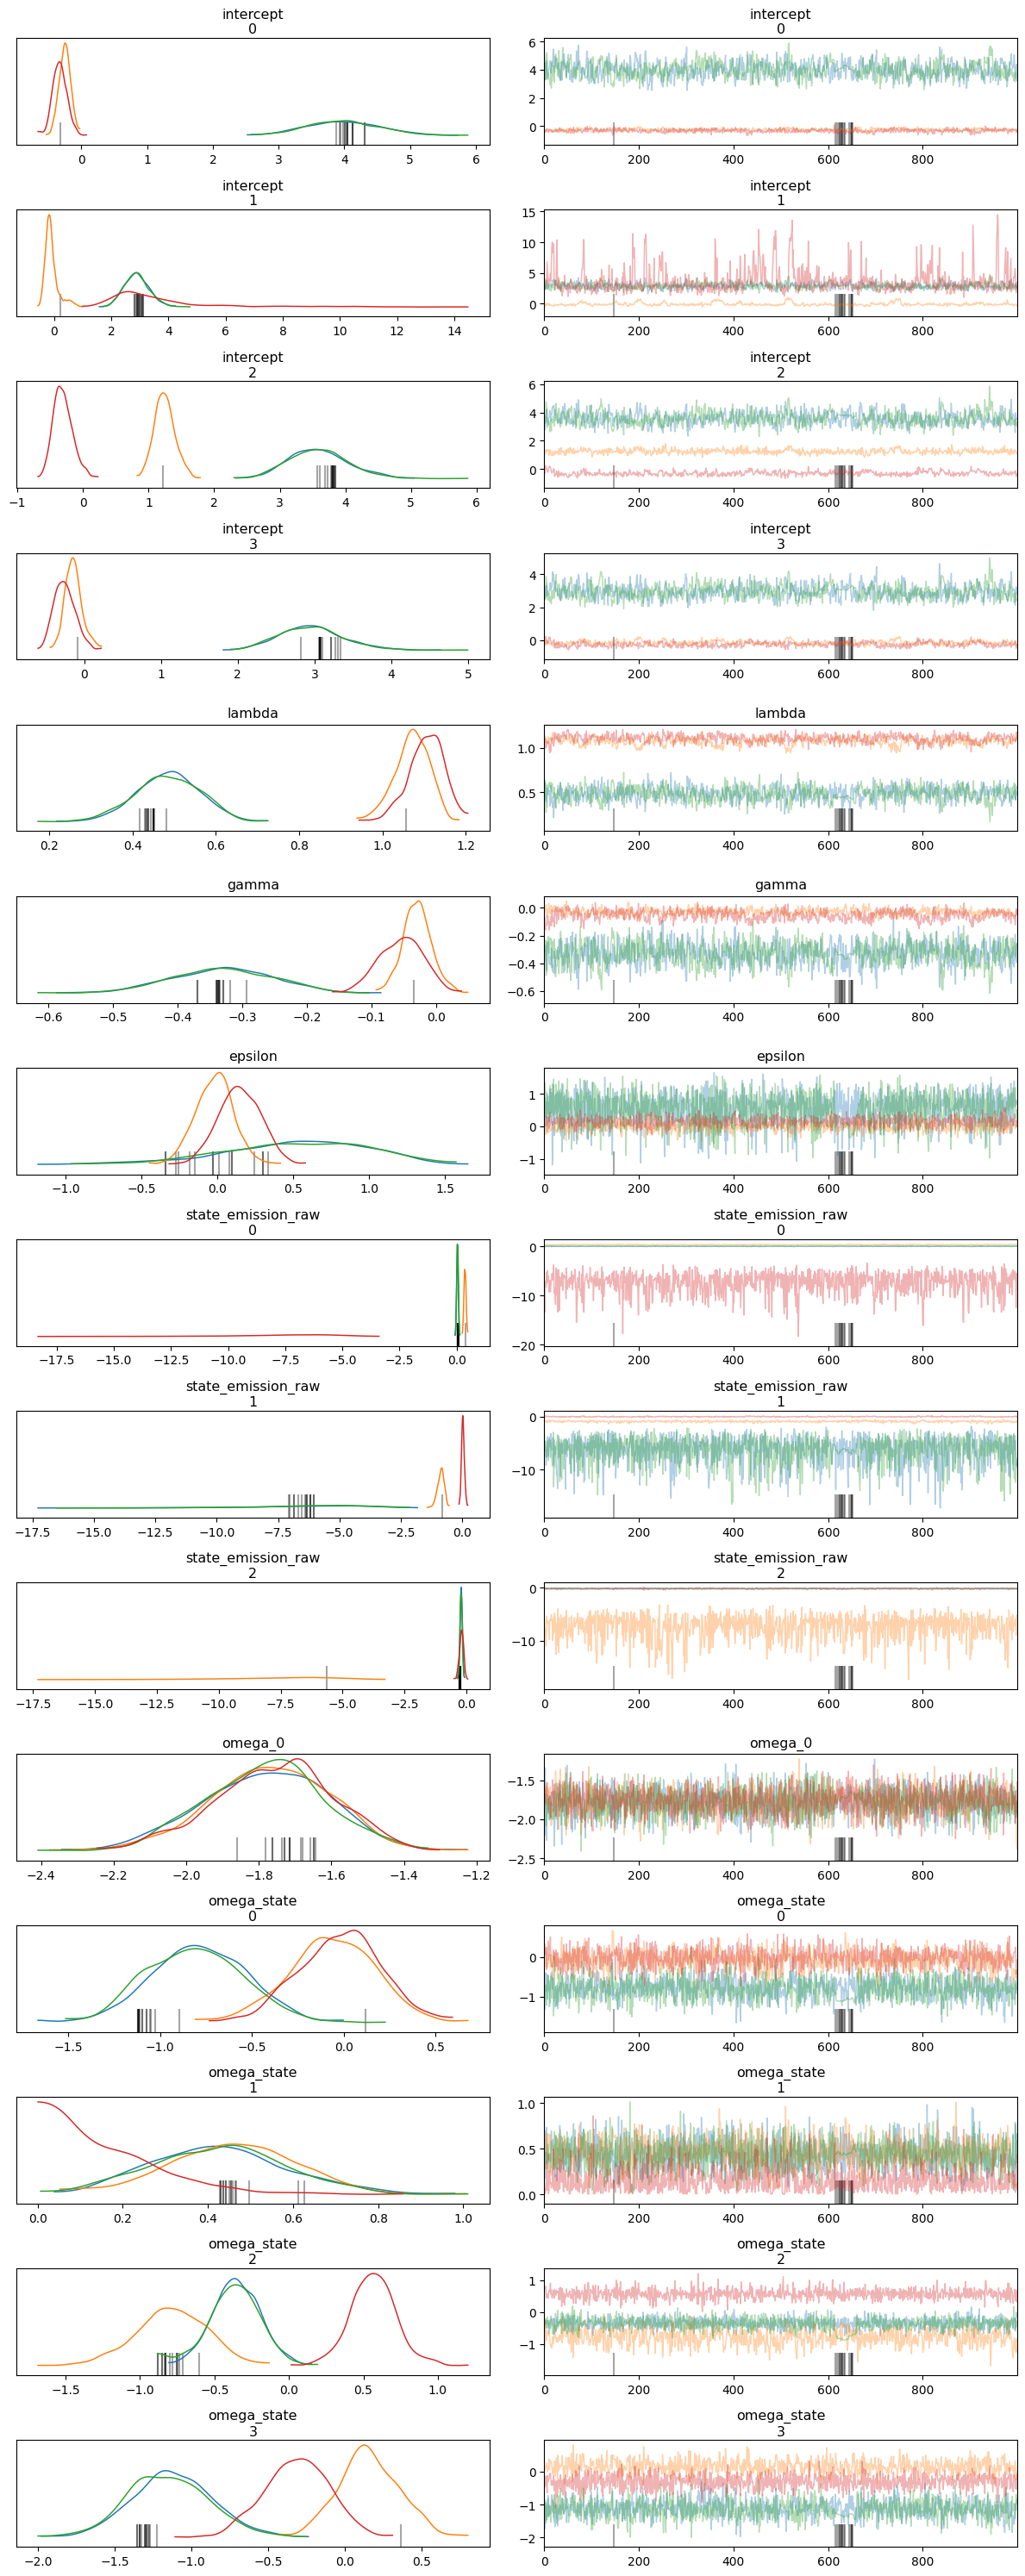

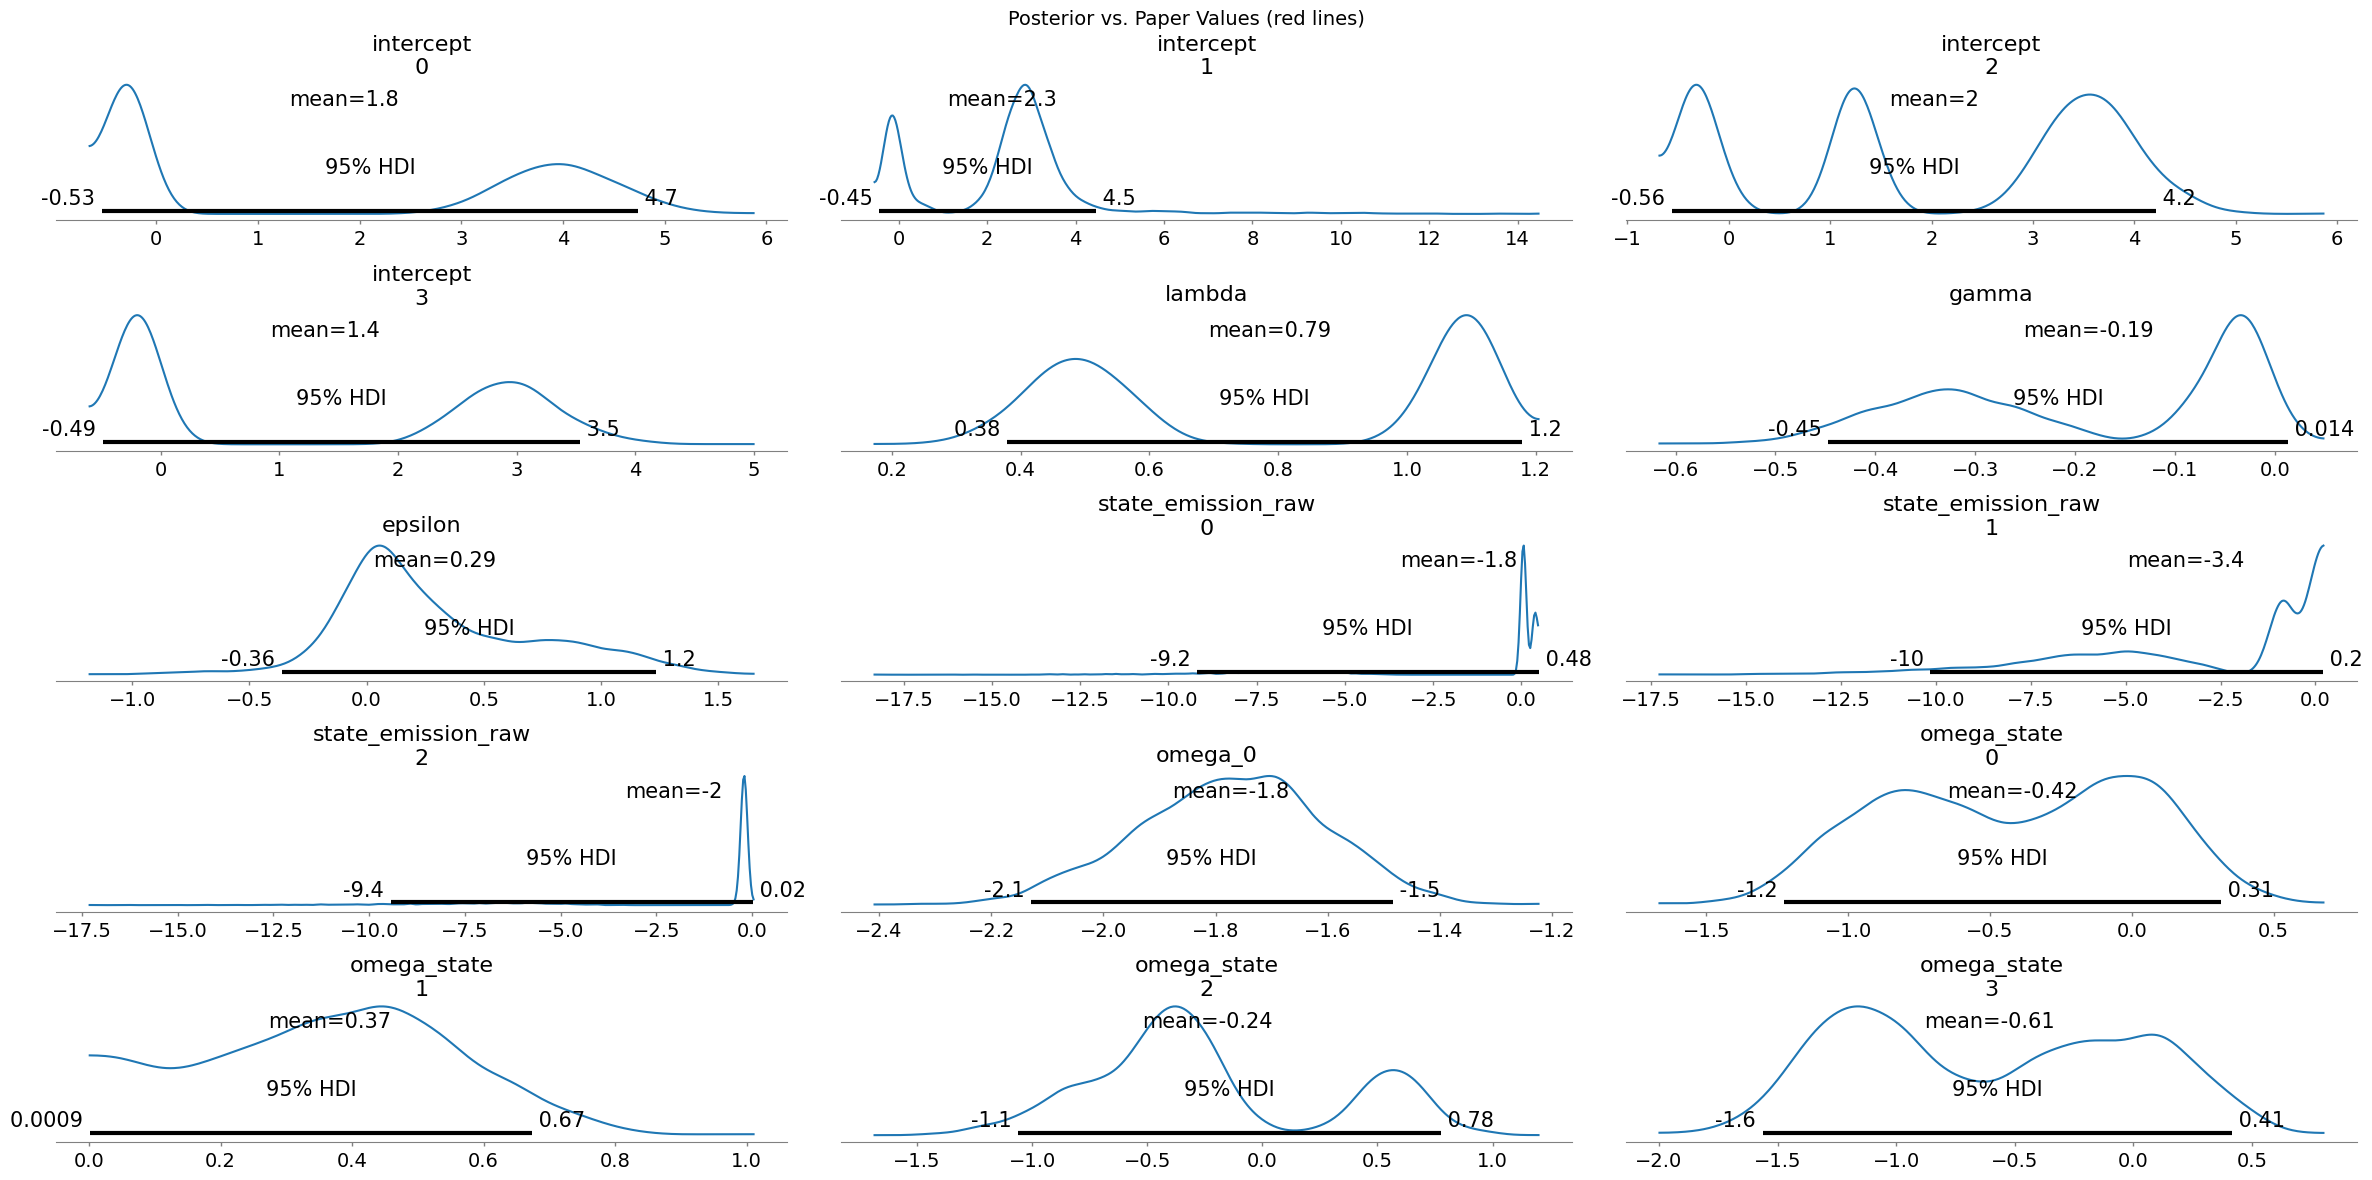

In [9]:
from constants import FITTED_MODEL_FOLDER_2000_ITER
from helpers import load_fitted_model
import arviz as az
import matplotlib.pyplot as plt

az.rcParams["stats.ci_prob"] = 0.95  # set CI to 95%

# Lade funktionierende Modelle
good_vdhmm3 = load_fitted_model("vdhmm", S=3)
bad_vdhmm4 = load_fitted_model("vdhmm", S=4)

# Vergleiche state_emission Posterior
good_summary = good_vdhmm3.summary
bad_summary = bad_vdhmm4.summary

for idx, fit in enumerate([good_vdhmm3.fit, bad_vdhmm4.fit]):
    print("=" * 60)
    print("GOOD FIT:" if idx == 0 else "BAD FIT:")
    print("=" * 60)
    # Konvertiere zu ArviZ InferenceData
    inference_data = az.from_cmdstanpy(fit)

    # Trace Plot für problematische Parameter
    az.plot_trace(
        inference_data,
        var_names=[
            "intercept",
            "lambda",
            "gamma",
            "epsilon",
            "state_emission_raw",
            "omega_0",
            "omega_state",
        ],
        compact=False,
    )
    plt.tight_layout()
    plt.show()

    az.plot_posterior(
        inference_data,
        var_names=[
            "intercept",
            "lambda",
            "gamma",
            "epsilon",
            "state_emission_raw",
            "omega_0",
            "omega_state",
        ],
        figsize=(24, 12),
    )
    plt.suptitle("Posterior vs. Paper Values (red lines)", fontsize=14)
    plt.tight_layout()
    plt.show()

    # # State emissions (wichtig für Label Switching)
    # az.plot_trace(inference_data, var_names=["state_emission"])
    # plt.show()

    # # Omega states
    # az.plot_trace(inference_data, var_names=["omega_state_raw", "omega_state_mid"])
    # plt.show()

In [8]:
# ============================================================================
# PARAMETER-VERGLEICH MIT NAUMZIK ET AL. (2022) PAPER
# ============================================================================

print("=" * 80)
print("DIAGNOSE: COMPARING WITH PAPER RESULTS (Naumzik et al., 2022)")
print("=" * 80)

# Paper-values out of table 4 (page p.199)
paper_values = {
    "intercept": -1.8205,
    "omega_state[1]": -0.3239,  # Well-running state
    "omega_state[2]": 0.8862,  # At-risk state
    "omega_state[3]": 0.2559,  # Bad-ratings-but-running state
}

print("\n1. STATE-FAILURE EMISSION COMPONENT (ω-Parameter)")
print("-" * 80)

# Vergleichstabelle
print(
    f"{'Parameter':<40} | {'values of replication':>12} | {'original results':>12} | {'difference':>12} | status"
)
print("-" * 95)

# Intercept
if "omega_0" in good_summary.index:
    your_intercept = good_summary.loc["omega_0", "Mean"]
    paper_intercept = paper_values["intercept"]
    diff_intercept = your_intercept - paper_intercept
    status = "✓" if abs(diff_intercept) < 0.2 else "✗"
    print(
        f"{'Intercept (ω₀)':<40} | {your_intercept:>12.4f} | {paper_intercept:>12.4f} | {diff_intercept:>+12.4f} | {status}"
    )

print()

# Latent State Durations
for i in range(1, 4):
    param_name = f"omega_state[{i}]"
    if param_name in good_summary.index:
        your_val = good_summary.loc[param_name, "Mean"]
        paper_val = paper_values[param_name]
        diff = your_val - paper_val
        status = "✓" if abs(diff) < 0.5 else "✗✗" if abs(diff) > 1.5 else "✗"

        state_names = {
            1: "Well-running state (ω₁)",
            2: "At-risk state (ω₂)",
            3: "Bad-ratings-but-running (ω₃)",
        }

        print(
            f"{state_names[i]:<40} | {your_val:>12.4f} | {paper_val:>12.4f} | {diff:>+12.4f} | {status}"
        )

# Zusätzliche Parameter (nicht im Paper berichtet)
print("\n\n2. VARIABLE-DURATION TRANSITION COMPONENT")
print("-" * 80)
print(f"{'parameters':<40} | {'values of replication':>12} | {'interpretation'}")
print("-" * 80)

transition_params = {
    "lambda": ("λ₁: State duration effect", "Duration dependency"),
    "gamma": ("λ₂: Time between ratings", "Calendar time effect"),
    "epsilon": ("λ₃: Review sentiment", "Sentiment effect"),
}

for param, (name, interpretation) in transition_params.items():
    if param in good_summary.index:
        val = good_summary.loc[param, "Mean"]
        print(f"{name:<40} | {val:>12.4f} | {interpretation}")

# State Emission Intercepts
print("\n\n3. STATE-RATING EMISSION (Intercepts ηs)")
print("-" * 80)
print(f"{'state':<40} | {'values of replication':>12} | {'interpretation'}")
print("-" * 80)

for i in range(1, 4):
    param_name = f"intercept[{i}]"
    if param_name in good_summary.index:
        val = good_summary.loc[param_name, "Mean"]
        print(
            f"{f'State {i} (η{i})':<40} | {val:>12.4f} | Higher = more positive ratings"
        )

DIAGNOSE: VERGLEICH MIT PAPER (Naumzik et al., 2022)

1. STATE-FAILURE EMISSION COMPONENT (ω-Parameter)
--------------------------------------------------------------------------------
Parameter                                | values of replication | original results |   difference | status
-----------------------------------------------------------------------------------------------
Intercept (ω₀)                           |      -1.8026 |      -1.8205 |      +0.0179 | ✓

Well-running state (ω₁)                  |      -0.9680 |      -0.3239 |      -0.6441 | ✗
At-risk state (ω₂)                       |       0.1143 |       0.8862 |      -0.7719 | ✗
Bad-ratings-but-running (ω₃)             |      -1.5281 |       0.2559 |      -1.7840 | ✗✗


2. VARIABLE-DURATION TRANSITION COMPONENT
--------------------------------------------------------------------------------
parameters                               | values of replication | interpretation
------------------------------------------